# Hybrid Recommender Optimization Analysis

Compare metrics and latency across different recommender configurations:
1. Retrieval-only (no reranker) - baseline
2. Hybrid with different candidate sizes (15, 50, 150)
3. Hybrid with different smaller feature subset (legacy)

In [10]:
# Setup project root
import rootutils
ROOT_DIR = rootutils.setup_root(".", indicator="pyproject.toml", pythonpath=True)
print(f"Project root: {ROOT_DIR}")

Project root: /Users/denys.koval/Labs/projects/coffee-recipe-recommender


In [11]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

from coffee_recipe_recommender.evaluation.metrics import evaluate_recommendations
from coffee_recipe_recommender.inference.recommender import Recommender
from coffee_recipe_recommender.training.loaders import load_interactions, load_recipes, load_users

## Configuration

In [12]:
# Paths
DATA_DIR = ROOT_DIR / "data"
RETRIEVAL_CHECKPOINT = ROOT_DIR / "runs/retrieval/baseline/retrieval_final.pt"
RANKER_MODEL = ROOT_DIR / "runs/ranking/very-advanced-features/ranker.pkl"
FEATURE_STORE = ROOT_DIR / "data/feature_store.db"
VECTOR_STORE = ROOT_DIR / "data/chroma"
COLD_START = ROOT_DIR / "runs/retrieval/cold_encoder_baseline/cold_encoder.pt"

# Evaluation settings
K = 5
MIN_RATING = 3.0
MAX_USERS = 2000  # Limit users for faster benchmarking

# Device
import torch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

Device: cpu


## Load Data

In [13]:
users_df = load_users(DATA_DIR / "users.csv")
recipes_df = load_recipes(DATA_DIR / "recipes.csv")
val_df = load_interactions(DATA_DIR / "interactions_val.csv")
train_df = load_interactions(DATA_DIR / "interactions_train_split.csv")

print(f"Users: {len(users_df)}, Recipes: {len(recipes_df)}")
print(f"Validation interactions: {len(val_df)}")

Users: 2000, Recipes: 150
Validation interactions: 25299


In [14]:
# Build ground truth
def build_ground_truth(interactions_df, min_rating=3.5):
    ground_truth = {}
    for _, row in interactions_df.iterrows():
        user_id = row["user_id"]
        recipe_id = row["recipe_id"]
        rating = row.get("rating")
        completed = row.get("completed", False)
        is_positive = (pd.notna(rating) and rating >= min_rating) or completed
        if is_positive:
            if user_id not in ground_truth:
                ground_truth[user_id] = set()
            ground_truth[user_id].add(recipe_id)
    return ground_truth

ground_truth = build_ground_truth(val_df, MIN_RATING)
user_ids = list(ground_truth.keys())[:MAX_USERS]
print(f"Evaluating {len(user_ids)} users with positive interactions")

Evaluating 1607 users with positive interactions


## Define Configurations

In [15]:
# Configuration matrix
CONFIGURATIONS = [
    {"name": "Retrieval-only", "mode": "retrieval", "candidate_size": None, "preset": "all"},
    {"name": "Hybrid-15-all", "mode": "hybrid", "candidate_size": 15, "preset": "all"},
    {"name": "Hybrid-50-all", "mode": "hybrid", "candidate_size": 50, "preset": "all"},
    {"name": "Hybrid-150-all", "mode": "hybrid", "candidate_size": 150, "preset": "all"},
    {
        "name": "Hybrid-50-legacy",
        "mode": "hybrid",
        "candidate_size": 50,
        "preset": "legacy",
        "ranker_path": ROOT_DIR / "runs/ranking/improved-features/ranker.pkl",
        "feature_store_path": ROOT_DIR / "data/legacy_feature_store.db"
    },
]
print(f"Testing {len(CONFIGURATIONS)} configurations")


Testing 5 configurations


## Evaluation Function

In [16]:
def evaluate_config(config, user_ids, users_df, recipes_df, train_df, ground_truth, k=5):
    """Evaluate a single configuration."""

    # Use config-specific paths if present, otherwise global defaults
    ranker_path = config.get("ranker_path", RANKER_MODEL)
    fs_path = config.get("feature_store_path", FEATURE_STORE)
    # Load recommender
    if config["mode"] == "retrieval":
        recommender = Recommender.from_retrieval_checkpoint(
            checkpoint_path=RETRIEVAL_CHECKPOINT,
            cold_start_path=COLD_START if COLD_START.exists() else None,
            vector_store_path=VECTOR_STORE,
            users_df=users_df,
            device=DEVICE,
        )
    else:  # hybrid
        recommender = Recommender.from_hybrid_checkpoints(
            retrieval_checkpoint_path=RETRIEVAL_CHECKPOINT,
            ranker_model_path=ranker_path,    # <--- Updated
            cold_start_path=COLD_START if COLD_START.exists() else None,
            users_df=users_df,
            recipes_df=recipes_df,
            candidate_size=config["candidate_size"],
            device=DEVICE,
            feature_store_path=fs_path,      # <--- Updated
            preset=config.get("preset"),
            vector_store_path=VECTOR_STORE
        )

    # Warmup
    for uid in user_ids[:3]:
        try:
            recommender.recommend(uid, users_df, recipes_df, train_df, n=k)
        except Exception:
            pass

    # Run evaluation with timing
    recommendations = {}
    latencies = []

    for uid in tqdm(user_ids, desc=config["name"], leave=False):
        try:
            start = time.perf_counter()
            recs = recommender.recommend(uid, users_df, recipes_df, train_df, n=k)
            latency = (time.perf_counter() - start) * 1000  # ms
            latencies.append(latency)
            recommendations[uid] = [recipe_id for recipe_id, _ in recs]
        except Exception:
            continue

    # Calculate metrics
    metrics = evaluate_recommendations(
        recommendations_dict=recommendations,
        ground_truth_dict=ground_truth,
        k=k,
        catalog_size=len(recipes_df),
    )

    # Add latency stats
    metrics["latency_mean_ms"] = np.mean(latencies)
    metrics["latency_p50_ms"] = np.percentile(latencies, 50)
    metrics["latency_p95_ms"] = np.percentile(latencies, 95)
    metrics["latency_p99_ms"] = np.percentile(latencies, 99)
    metrics["throughput_rps"] = 1000 / np.mean(latencies) if latencies else 0

    return metrics, latencies


## Run All Configurations

In [17]:
results = []
all_latencies = {}

for config in CONFIGURATIONS:
    print(f"\n🚀 Evaluating: {config['name']}")
    metrics, latencies = evaluate_config(
        config, user_ids, users_df, recipes_df, train_df, ground_truth, k=K
    )
    metrics["config"] = config["name"]
    results.append(metrics)
    all_latencies[config["name"]] = latencies

    print(f"   NDCG@{K}: {metrics.get(f'NDCG@{K}', 0):.4f}")
    print(f"   Latency: {metrics['latency_mean_ms']:.1f}ms (p95: {metrics['latency_p95_ms']:.1f}ms)")

results_df = pd.DataFrame(results)
print("\n✅ All configurations evaluated!")


🚀 Evaluating: Retrieval-only
✅ Vector store loaded: 150 embeddings from /Users/denys.koval/Labs/projects/coffee-recipe-recommender/data/chroma


Retrieval-only:   0%|          | 0/1607 [00:00<?, ?it/s]

   NDCG@5: 0.7182
   Latency: 20.1ms (p95: 21.5ms)

🚀 Evaluating: Hybrid-15-all
✅ Vector store loaded: 150 embeddings from /Users/denys.koval/Labs/projects/coffee-recipe-recommender/data/chroma
✅ Feature store loaded from /Users/denys.koval/Labs/projects/coffee-recipe-recommender/data/feature_store.db


Hybrid-15-all:   0%|          | 0/1607 [00:00<?, ?it/s]

   NDCG@5: 0.7828
   Latency: 83.4ms (p95: 87.4ms)

🚀 Evaluating: Hybrid-50-all
✅ Vector store loaded: 150 embeddings from /Users/denys.koval/Labs/projects/coffee-recipe-recommender/data/chroma
✅ Feature store loaded from /Users/denys.koval/Labs/projects/coffee-recipe-recommender/data/feature_store.db


...

   NDCG@5: 0.8012
   Latency: 83.8ms (p95: 90.8ms)

🚀 Evaluating: Hybrid-150-all
✅ Vector store loaded: 150 embeddings from /Users/denys.koval/Labs/projects/coffee-recipe-recommender/data/chroma
✅ Feature store loaded from /Users/denys.koval/Labs/projects/coffee-recipe-recommender/data/feature_store.db


Hybrid-150-all:   0%|          | 0/1607 [00:00<?, ?it/s]

   NDCG@5: 0.7919
   Latency: 91.8ms (p95: 98.8ms)

🚀 Evaluating: Hybrid-50-legacy
✅ Vector store loaded: 150 embeddings from /Users/denys.koval/Labs/projects/coffee-recipe-recommender/data/chroma
✅ Feature store loaded from /Users/denys.koval/Labs/projects/coffee-recipe-recommender/data/legacy_feature_store.db


Hybrid-50-legacy:   0%|          | 0/1607 [00:00<?, ?it/s]

   NDCG@5: 0.7672
   Latency: 62.1ms (p95: 65.3ms)

✅ All configurations evaluated!


## Results Comparison

In [18]:
# Display results table
display_cols = [
    "config",
    f"NDCG@{K}",
    f"Precision@{K}",
    f"Recall@{K}",
    "latency_mean_ms",
    "latency_p95_ms",
    "throughput_rps",
]
results_df[display_cols].round(4)

,config,NDCG@5,Precision@5,Recall@5,latency_mean_ms,latency_p95_ms,throughput_rps
0,Retrieval-only,0.7182,0.4780,0.4486,20.0819,21.5316,49.7961
1,Hybrid-15-all,0.7828,0.5330,0.4872,83.3583,87.3738,11.9964
2,Hybrid-50-all,0.8012,0.5355,0.4921,83.7771,90.8305,11.9364
3,Hybrid-150-all,0.7919,0.5223,0.4854,91.7860,98.7923,10.8949
4,Hybrid-50-legacy,0.7672,0.5021,0.4657,62.1151,65.2966,16.0991


## Visualizations

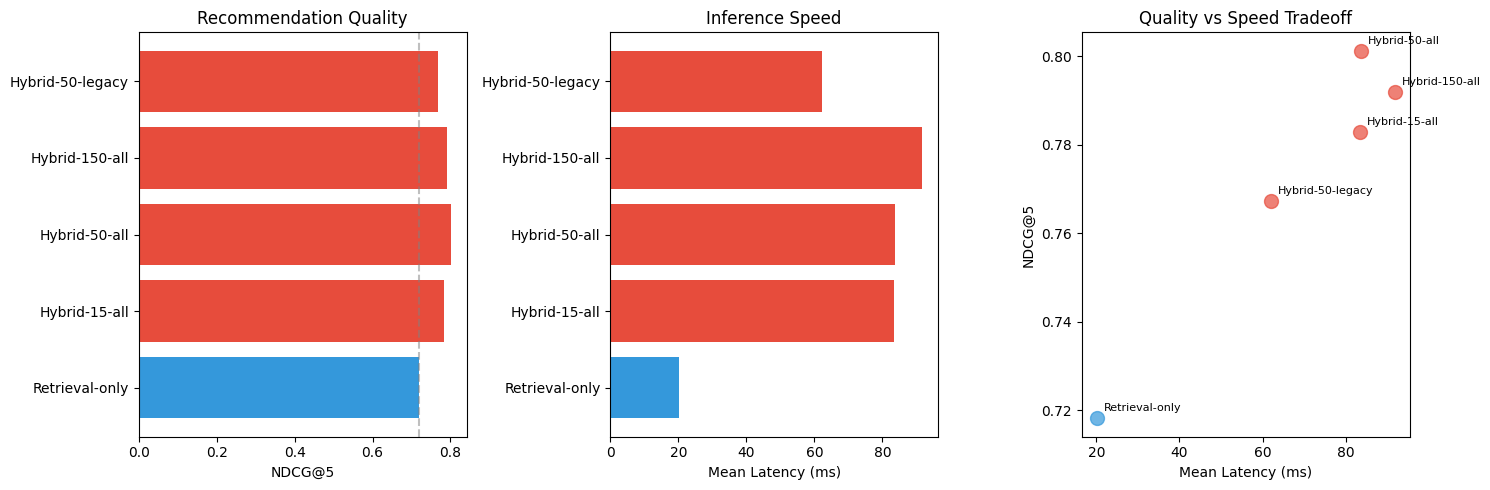


📊 Plot saved to notebooks/optimization_comparison.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# NDCG comparison
ax = axes[0]
configs = results_df["config"]
ndcg_vals = results_df[f"NDCG@{K}"]
colors = ["#3498db" if "Retrieval" in c else "#e74c3c" for c in configs]
ax.barh(configs, ndcg_vals, color=colors)
ax.set_xlabel(f"NDCG@{K}")
ax.set_title("Recommendation Quality")
ax.axvline(ndcg_vals.iloc[0], color="gray", linestyle="--", alpha=0.5, label="Baseline")

# Latency comparison
ax = axes[1]
ax.barh(configs, results_df["latency_mean_ms"], color=colors)
ax.set_xlabel("Mean Latency (ms)")
ax.set_title("Inference Speed")

# Quality vs Latency tradeoff
ax = axes[2]
for i, row in results_df.iterrows():
    color = "#3498db" if "Retrieval" in row["config"] else "#e74c3c"
    ax.scatter(row["latency_mean_ms"], row[f"NDCG@{K}"], s=100, c=color, alpha=0.7)
    ax.annotate(row["config"], (row["latency_mean_ms"], row[f"NDCG@{K}"]),
                xytext=(5, 5), textcoords="offset points", fontsize=8)
ax.set_xlabel("Mean Latency (ms)")
ax.set_ylabel(f"NDCG@{K}")
ax.set_title("Quality vs Speed Tradeoff")

plt.tight_layout()
plt.show()

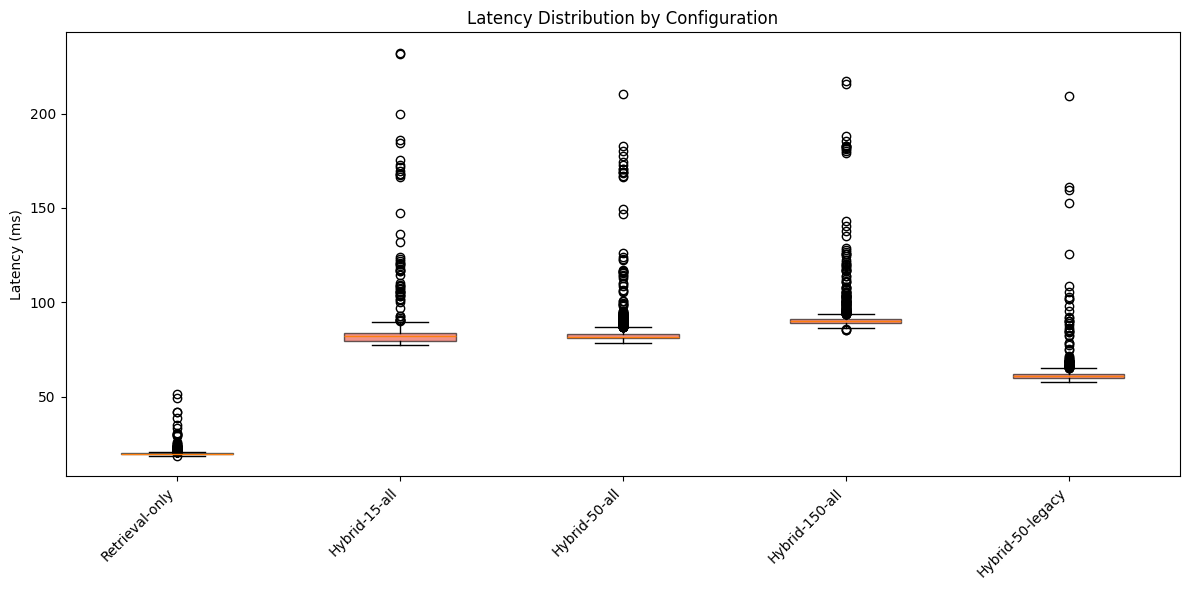


📊 Plot saved to notebooks/latency_distribution.png


In [ ]:
# Latency distribution boxplot
fig, ax = plt.subplots(figsize=(12, 6))

latency_data = [all_latencies[name] for name in results_df["config"]]
bp = ax.boxplot(latency_data, tick_labels=list(results_df["config"]), patch_artist=True)

colors = ["#3498db" if "Retrieval" in c else "#e74c3c" for c in results_df["config"]]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.set_ylabel("Latency (ms)")
ax.set_title("Latency Distribution by Configuration")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Summary & Recommendations

In [21]:
print("=" * 60)
print("OPTIMIZATION ANALYSIS SUMMARY")
print("=" * 60)

baseline = results_df[results_df["config"] == "Retrieval-only"].iloc[0]
best_quality = results_df.loc[results_df[f"NDCG@{K}"].idxmax()]
best_speed = results_df.loc[results_df["latency_mean_ms"].idxmin()]

print(f"\n📊 Baseline (Retrieval-only):")
print(f"   NDCG@{K}: {baseline[f'NDCG@{K}']:.4f}")
print(f"   Latency: {baseline['latency_mean_ms']:.1f}ms")

print(f"\n🏆 Best Quality ({best_quality['config']}):")
print(f"   NDCG@{K}: {best_quality[f'NDCG@{K}']:.4f} (+{(best_quality[f'NDCG@{K}'] - baseline[f'NDCG@{K}'])*100:.1f}%)")
print(f"   Latency: {best_quality['latency_mean_ms']:.1f}ms")

print(f"\n⚡ Best Speed ({best_speed['config']}):")
print(f"   NDCG@{K}: {best_speed[f'NDCG@{K}']:.4f}")
print(f"   Latency: {best_speed['latency_mean_ms']:.1f}ms")

# Find best tradeoff (highest NDCG per ms of latency)
results_df["efficiency"] = results_df[f"NDCG@{K}"] / results_df["latency_mean_ms"]
best_tradeoff = results_df.loc[results_df["efficiency"].idxmax()]

print(f"\n⚖️ Best Tradeoff ({best_tradeoff['config']}):")
print(f"   NDCG@{K}: {best_tradeoff[f'NDCG@{K}']:.4f}")
print(f"   Latency: {best_tradeoff['latency_mean_ms']:.1f}ms")
print(f"   Efficiency: {best_tradeoff['efficiency']:.6f} NDCG/ms")

print("\n" + "=" * 60)

OPTIMIZATION ANALYSIS SUMMARY

📊 Baseline (Retrieval-only):
   NDCG@5: 0.7182
   Latency: 20.1ms

🏆 Best Quality (Hybrid-50-all):
   NDCG@5: 0.8012 (+8.3%)
   Latency: 83.8ms

⚡ Best Speed (Retrieval-only):
   NDCG@5: 0.7182
   Latency: 20.1ms

⚖️ Best Tradeoff (Retrieval-only):
   NDCG@5: 0.7182
   Latency: 20.1ms
   Efficiency: 0.035763 NDCG/ms

